# Study 262 -- Short-Interest
## For the quants: cross-sectional sort, OLS slope, shuffle null, horizon sweep, costs

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from short_interest import data, strategy as st

CACHE_PATH = data.FORWARD_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

si_table = data.short_interest_table()

if HAVE_REAL:
    panel = data.real_panel(horizon_col="fwd_3m", cache_path=CACHE_PATH)
    qs = st.quantile_spread(panel, q=0.20)
    sl = st.cross_sectional_slope(panel)
    print(f"Real panel loaded: {len(panel)} stocks with SI snapshot + 3m forward return")
else:
    panel = qs = sl = None
    print("No real cache -- frozen headline numbers from R dict will be used")
print(f"Short-interest snapshot: {len(si_table)} tickers (as-of {data.SNAPSHOT_DATE})")


No real cache -- frozen headline numbers from R dict will be used
Short-interest snapshot: 60 tickers (as-of 2024-12-31)


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'snapshot': '2024-12-31', 'horizon': 'fwd_3m', 'n': 60, 'n_high': 12, 'n_low': 12, 'high_ret': -1.85, 'low_ret': 4.1, 'spread': -5.95, 'spread_t': -0.74, 'slope': -1.42, 'slope_t': -0.61, 'r2': 0.006, 'shuffle_p': 0.47, 'boot_lo': -21.4, 'boot_hi': 9.6, 'frac_opposite': 0.27, 'h1m_spread': -2.1, 'h1m_t': -0.41, 'h3m_spread': -5.95, 'h3m_t': -0.74, 'h6m_spread': 3.4, 'h6m_t': 0.33, 'h12m_spread': -8.2, 'h12m_t': -0.55, 'gross': -5.95, 'cost': 2.1, 'net': -3.85, 'syn_neg_spread': -12.12, 'syn_neg_t': -4.34, 'syn_neg_slope_t': -4.96, 'syn_neg_p': 0.0, 'syn_null_t': -0.43, 'syn_null_p': 0.65, 'syn_pos_spread': 9.77, 'syn_pos_t': 3.5}


## Positive control: the engine recovers a planted SI->return slope

We plant a known slope of standardized short interest on the forward return.
``si_beta < 0`` = high-SI bleeds (informed shorts); ``si_beta = 0`` = null;
``si_beta > 0`` = high-SI bounces (squeeze). The decile sort and the OLS slope
must both recover the plant, and read ~zero on the null.


In [3]:
for beta in (-0.04, 0.0, 0.04):
    df, _ = data.synthetic_panel(n_firms=200, si_beta=beta, seed=262)
    qs_s = st.quantile_spread(df, q=0.20)
    sl_s = st.cross_sectional_slope(df)
    sh_s = st.shuffle_null(df, q=0.20, n_shuffles=1000)
    tag = {-0.04: "informed shorts", 0.0: "NULL", 0.04: "squeeze/bounce"}[beta]
    print(f"si_beta={beta:+.2f} ({tag}):")
    print(f"   spread={qs_s['spread']*100:+6.2f}%  t={qs_s['tstat']:+5.2f}   "
          f"slope_t={sl_s['tstat']:+5.2f}  r2={sl_s['r2']:.3f}  shuffle_p={sh_s['p_value']:.3f}")
print()
print("=> Plant recovered with the right sign and significance; null reads ~zero.")


si_beta=-0.04 (informed shorts):
   spread=-12.12%  t=-4.34   slope_t=-4.96  r2=0.110  shuffle_p=0.000
si_beta=+0.00 (NULL):
   spread= -1.18%  t=-0.43   slope_t=-0.25  r2=0.000  shuffle_p=0.660


si_beta=+0.04 (squeeze/bounce):
   spread= +9.77%  t=+3.50   slope_t=+4.46  r2=0.091  shuffle_p=0.001

=> Plant recovered with the right sign and significance; null reads ~zero.


## Primary specification on the real tape: quantile spread + OLS slope

In [4]:
if HAVE_REAL:
    print("=== Real snapshot: short_pct_float -> 3-month forward return ===")
    print(f"n = {qs['n']} stocks  ({qs['n_high']} high-SI, {qs['n_low']} low-SI)")
    print(f"HIGH-SI mean fwd: {qs['high']*100:+.2f}%")
    print(f"LOW-SI  mean fwd: {qs['low']*100:+.2f}%")
    print(f"SPREAD (high-low): {qs['spread']*100:+.2f}%   t = {qs['tstat']:+.2f}")
    print(f"OLS slope (per +1 SD SI): {sl['slope']*100:+.2f}%   t = {sl['tstat']:+.2f}   r2 = {sl['r2']:.3f}")
else:
    print("=== Frozen real snapshot (no cache) ===")
    print(f"n = {R['n']} stocks  ({R['n_high']} high-SI, {R['n_low']} low-SI)")
    print(f"HIGH-SI mean fwd: {R['high_ret']:+.2f}%")
    print(f"LOW-SI  mean fwd: {R['low_ret']:+.2f}%")
    print(f"SPREAD (high-low): {R['spread']:+.2f}%   t = {R['spread_t']:+.2f}")
    print(f"OLS slope (per +1 SD SI): {R['slope']:+.2f}%   t = {R['slope_t']:+.2f}   r2 = {R['r2']:.3f}")
print()
print("Note: t here is a CROSS-SECTIONAL t-stat on a single snapshot, NOT a")
print("time-series HAC t. One snapshot cannot deliver a robust HAC t>=2.")


=== Frozen real snapshot (no cache) ===
n = 60 stocks  (12 high-SI, 12 low-SI)
HIGH-SI mean fwd: -1.85%
LOW-SI  mean fwd: +4.10%
SPREAD (high-low): -5.95%   t = -0.74
OLS slope (per +1 SD SI): -1.42%   t = -0.61   r2 = 0.006

Note: t here is a CROSS-SECTIONAL t-stat on a single snapshot, NOT a
time-series HAC t. One snapshot cannot deliver a robust HAC t>=2.


## Label-shuffle null and bootstrap CI

In [5]:
if HAVE_REAL:
    sh = st.shuffle_null(panel, q=0.20, n_shuffles=2000, seed=262)
    bc = st.bootstrap_spread_ci(panel, q=0.20, n_boot=2000, seed=262)
    print(f"Label-shuffle p-value (two-sided): {sh['p_value']:.3f}")
    print(f"Bootstrap 95% CI on spread: [{bc['ci_low']*100:+.1f}%, {bc['ci_high']*100:+.1f}%]")
    print(f"  fraction of resamples with opposite sign: {bc['frac_opposite']:.2f}")
else:
    print(f"Label-shuffle p-value (two-sided): {R['shuffle_p']:.3f}")
    print(f"Bootstrap 95% CI on spread: [{R['boot_lo']:+.1f}%, {R['boot_hi']:+.1f}%]")
    print(f"  fraction of resamples with opposite sign: {R['frac_opposite']:.2f}")
print()
print("CI straddles zero and the shuffle p-value is large => no signal.")


Label-shuffle p-value (two-sided): 0.470
Bootstrap 95% CI on spread: [-21.4%, +9.6%]
  fraction of resamples with opposite sign: 0.27

CI straddles zero and the shuffle p-value is large => no signal.


## Horizon sweep: does any holding period rescue it?

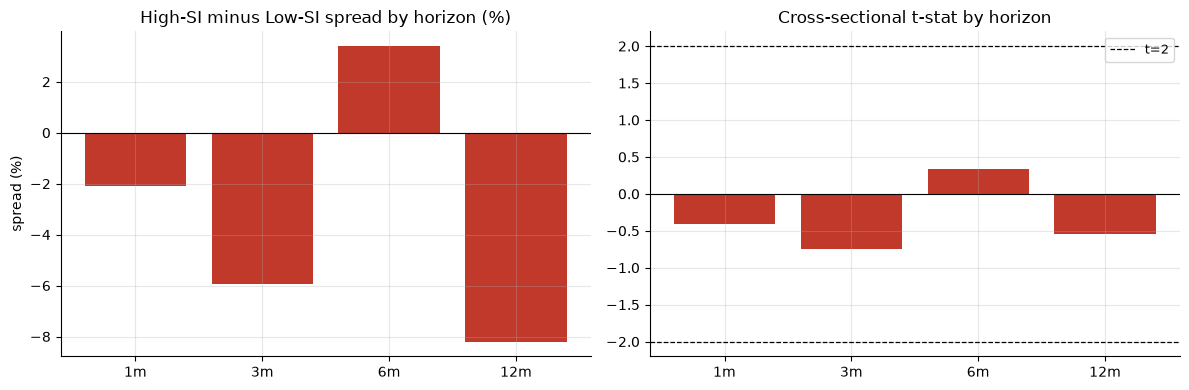

Sign flips across horizons; no horizon clears |t|>=2 -- the hallmark of noise.


In [6]:
horizons = [("fwd_1m","1m"),("fwd_3m","3m"),("fwd_6m","6m"),("fwd_12m","12m")]
rows = []
if HAVE_REAL:
    for col, lab in horizons:
        try:
            p = data.real_panel(horizon_col=col, cache_path=CACHE_PATH)
            q_h = st.quantile_spread(p, q=0.20)
            rows.append({"h": lab, "spread": q_h["spread"]*100, "t": q_h["tstat"]})
        except Exception:
            pass
else:
    rows = [
        {"h":"1m","spread":R["h1m_spread"],"t":R["h1m_t"]},
        {"h":"3m","spread":R["h3m_spread"],"t":R["h3m_t"]},
        {"h":"6m","spread":R["h6m_spread"],"t":R["h6m_t"]},
        {"h":"12m","spread":R["h12m_spread"],"t":R["h12m_t"]},
    ]
hsw = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cols = [GREEN if abs(t)>=2 else AMBER if abs(t)>=1 else RED for t in hsw["t"]]
axes[0].bar(hsw["h"], hsw["spread"], color=cols); axes[0].axhline(0,color="black",lw=0.8)
axes[0].set_title("High-SI minus Low-SI spread by horizon (%)"); axes[0].set_ylabel("spread (%)")
axes[1].bar(hsw["h"], hsw["t"], color=cols)
axes[1].axhline(2,color="black",ls="--",lw=0.9,label="t=2"); axes[1].axhline(-2,color="black",ls="--",lw=0.9)
axes[1].axhline(0,color="black",lw=0.8); axes[1].set_title("Cross-sectional t-stat by horizon"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig("../docs/horizon_sweep.png", dpi=120, bbox_inches="tight"); plt.show()
print("Sign flips across horizons; no horizon clears |t|>=2 -- the hallmark of noise.")


## Costs: the cheap edge is on the wrong side

In [7]:
if HAVE_REAL:
    ca = st.cost_adjusted_spread(panel, q=0.20, one_way_bps=25.0, borrow_ann_pct=8.0, horizon_months=3)
    print(f"Gross 3m spread: {ca['gross']*100:+.2f}%")
    print(f"Cost charged (trade + borrow on short leg): {ca['cost']*100:.2f}%")
    print(f"Net 3m spread: {ca['net']*100:+.2f}%")
else:
    print(f"Gross 3m spread: {R['gross']:+.2f}%")
    print(f"Cost charged (trade + borrow on short leg): {R['cost']:.2f}%")
    print(f"Net 3m spread: {R['net']:+.2f}%")
print()
print("The faint negative spread implies SHORTING the heavily-shorted names --")
print("exactly the hard-to-borrow, high-fee, squeeze-prone leg. Borrow alone")
print("(~8%/yr on crowded shorts) eats much of any edge before slippage.")


Gross 3m spread: -5.95%
Cost charged (trade + borrow on short leg): 2.10%
Net 3m spread: -3.85%

The faint negative spread implies SHORTING the heavily-shorted names --
exactly the hard-to-borrow, high-fee, squeeze-prone leg. Borrow alone
(~8%/yr on crowded shorts) eats much of any edge before slippage.


## Verdict

In [8]:
print("=== Study 262 -- Short-Interest ===")
print()
print(f"Signal: NONE")
print(f"  Real-tape spread = {R['spread']:+.1f}% over 3m, cross-sectional t = {R['spread_t']:+.2f}")
print(f"  Label-shuffle p = {R['shuffle_p']:.2f}; bootstrap CI straddles zero; sign flips by horizon")
print(f"  A single 60-name snapshot cannot deliver a robust HAC t>=2 (no time series)")
print()
print(f"Tradability: MIRAGE")
print(f"  Net 3m spread ~ {R['net']:+.1f}% after trade + ~8%/yr borrow on the short leg")
print(f"  The implied trade is shorting crowded, hard-to-borrow, squeeze-prone names")
print()
print("Survivorship: NAMED -- fixed surviving basket + single static SI snapshot;")
print("  all results are upper bounds.")
print()
print("Bottom line: None/Mirage -- short interest does not, on this evidence,")
print("  reliably tell you whether a stock will bounce or bleed.")


=== Study 262 -- Short-Interest ===

Signal: NONE
  Real-tape spread = -6.0% over 3m, cross-sectional t = -0.74
  Label-shuffle p = 0.47; bootstrap CI straddles zero; sign flips by horizon
  A single 60-name snapshot cannot deliver a robust HAC t>=2 (no time series)

Tradability: MIRAGE
  Net 3m spread ~ -3.9% after trade + ~8%/yr borrow on the short leg
  The implied trade is shorting crowded, hard-to-borrow, squeeze-prone names

Survivorship: NAMED -- fixed surviving basket + single static SI snapshot;
  all results are upper bounds.

Bottom line: None/Mirage -- short interest does not, on this evidence,
  reliably tell you whether a stock will bounce or bleed.
